In [15]:
# Cell 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data (Handling relative path)
try:
    df = pd.read_csv('../puerto_rico_master_profile_2010_2024.csv')
    print("✅ File loaded from parent directory!")
except FileNotFoundError:
    try:
        df = pd.read_csv('puerto_rico_master_profile_2010_2024.csv')
        print("✅ File loaded from current directory!")
    except FileNotFoundError:
        print("❌ Error: File not found. Please check the file path.")

# Define the Metrics mapping (Website Section -> CSV Column)
METRICS = {
    "👥 Population": "total_population",
    "📈 Unemployment Rate": "unemployment_rate_pct",
    "💵 Real Median Income": "median_income_real",
    "🏠 Housing Units": "total_housing_units",
    "🎓 Education (Bachelor's+)": "bachelors_plus_pct",
    "🏥 Uninsured Rate": "uninsured_pct",
    "🏢 Business Establishments": "establishment_count"
}

print(f"Data Loaded. Ready to forecast {len(METRICS)} key metrics.")
df.head()

✅ File loaded from parent directory!
Data Loaded. Ready to forecast 7 key metrics.


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,hs_graduate_pct,hs_graduate_count,hs_graduate_moe,bachelors_plus_pct,bachelors_count,doctorate_count,doctorate_moe,establishment_count,uninsured_pct,uninsured_moe
0,2010,Adjuntas Municipio,72001,19541.0,0.0,14834.0,99.0,6548.0,133.0,20.7,...,38.7,2956.0,305.551960,14.6,1782.0,0.0,173.948268,120.0,NaN,NaN
1,2010,Aguada Municipio,72003,42232.0,0.0,32967.0,119.0,16022.0,208.0,25.6,...,41.7,6814.0,494.886856,16.7,4561.0,131.0,70.292247,465.0,NaN,NaN
2,2010,Aguadilla Municipio,72005,61965.0,0.0,48666.0,160.0,25252.0,267.0,20.8,...,44.9,10860.0,655.045800,18.3,7470.0,351.0,117.153745,833.0,NaN,NaN
3,2010,Aguas Buenas Municipio,72007,28827.0,0.0,22236.0,97.0,10579.0,158.0,4.1,...,41.2,4657.0,367.915751,16.0,2944.0,21.0,24.413111,142.0,NaN,NaN
4,2010,Aibonito Municipio,72009,26161.0,0.0,20267.0,99.0,9355.0,109.0,14.4,...,45.9,4537.0,376.860717,18.8,3140.0,68.0,50.606324,280.0,NaN,NaN


In [16]:
# Cell 2: The Forecasting Engine (Enhanced with Events & Export)
import json

# Dictionary to store results for export
forecast_results = {}

def forecast_metric(metric_name, col_name, df):
    print(f"\n🔵 FORECASTING: {metric_name} ({col_name})")
    
    # 1. Aggregate Island-Wide
    if col_name in ['total_population', 'total_housing_units', 'establishment_count']:
        trend = df.groupby('year')[col_name].sum().reset_index()
    else:
        trend = df.groupby('year')[col_name].mean().reset_index()
    
    trend = trend.dropna()
    
    # Data Split
    train = trend[trend['year'] < 2020]
    test = trend[trend['year'] >= 2020]
    
    # Fallback for short data
    if len(test) == 0:
        train = trend.iloc[:-3]
        test = trend.iloc[-3:]

    X_train = train['year'].values.reshape(-1, 1)
    y_train = trend.loc[train.index, col_name].values
    X_test = test['year'].values.reshape(-1, 1)
    y_test = trend.loc[test.index, col_name].values

    # Train & Test
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"   📊 Model Accuracy (MAE): +/- {mae:,.2f}")
    
    # Future Forecast (2025-2030)
    X_all = trend['year'].values.reshape(-1, 1)
    y_all = trend[col_name].values
    model.fit(X_all, y_all)
    
    future_years = np.array([2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
    future_pred = model.predict(future_years)
    
    # --- SAVE RESULTS FOR JSON ---
    forecast_results[col_name] = {
        "history": trend.set_index('year')[col_name].to_dict(),
        "forecast": dict(zip(future_years.flatten().astype(str), future_pred)),
        "mae": mae
    }
    
    # --- VISUALIZATION WITH SHOCKS ---
    plt.figure(figsize=(12, 6))
    
    # Plot History & Forecast
    plt.plot(trend['year'], trend[col_name], label='Historical Data', marker='o', color='navy', linewidth=2.5)
    plt.plot(future_years, future_pred, label='Forecast (2025-2030)', linestyle='--', marker='x', color='crimson', linewidth=2.5)
    
    # Add "Shock" Annotations (The Storytelling Layer)
    plt.axvline(x=2017, color='orange', linestyle=':', alpha=0.8)
    plt.text(2017.1, plt.ylim()[0] + (plt.ylim()[1]-plt.ylim()[0])*0.05, 'Maria (2017)', color='orange', rotation=90, fontweight='bold')
    
    plt.axvline(x=2020, color='gray', linestyle=':', alpha=0.8)
    plt.text(2020.1, plt.ylim()[0] + (plt.ylim()[1]-plt.ylim()[0])*0.05, 'Earthquakes/COVID (2020)', color='gray', rotation=90, fontweight='bold')
    
    plt.title(f'Puerto Rico Projection: {metric_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# After running all metrics, run this snippet to save the JSON
def save_forecasts():
    with open('forecast_data.json', 'w') as f:
        json.dump(forecast_results, f, indent=4)
    print("✅ Forecast data saved to 'forecast_data.json'")


🔵 FORECASTING: 👥 Population (total_population)
   📊 Model Accuracy (MAE): +/- 78,292.91


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


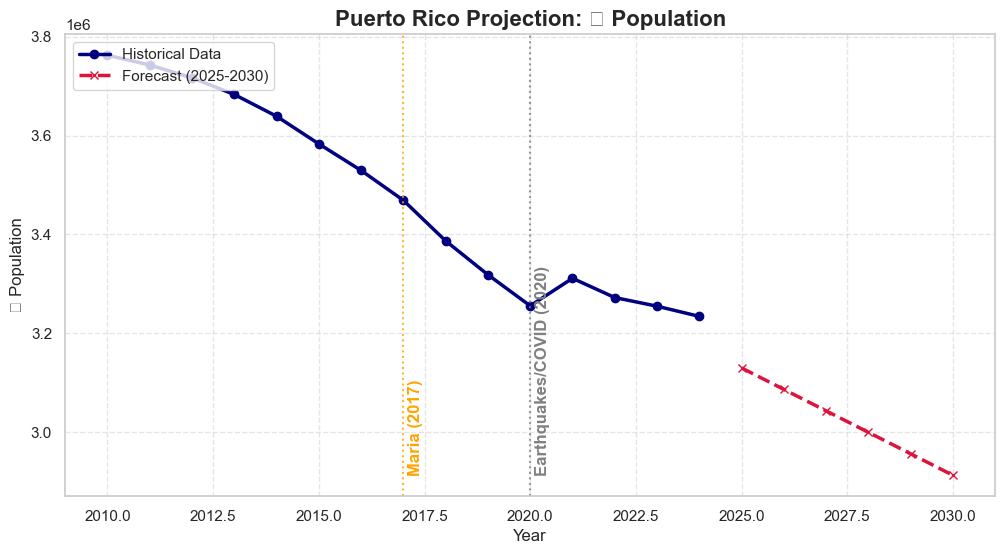


🔵 FORECASTING: 📈 Unemployment Rate (unemployment_rate_pct)
   📊 Model Accuracy (MAE): +/- 4.69


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


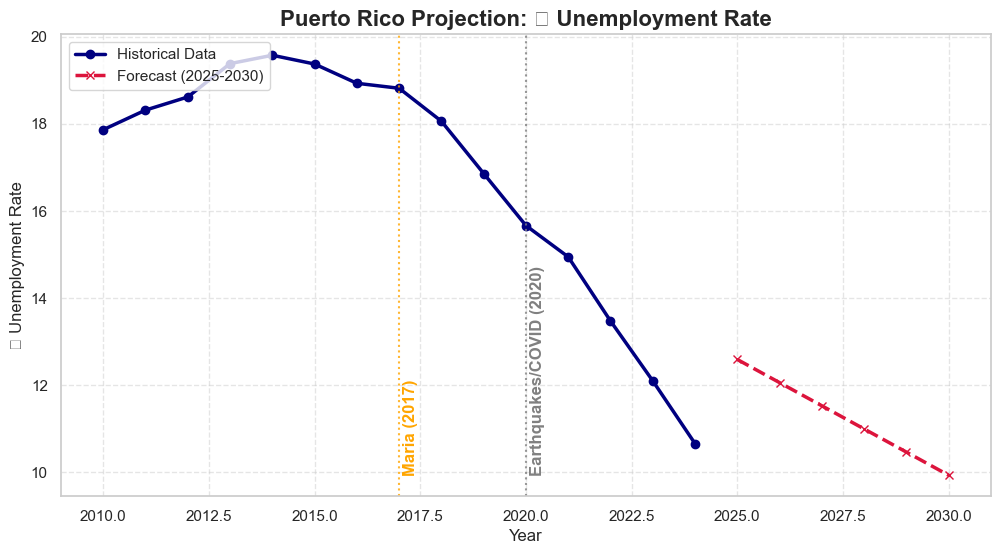


🔵 FORECASTING: 💵 Real Median Income (median_income_real)
   📊 Model Accuracy (MAE): +/- 1,267.57


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


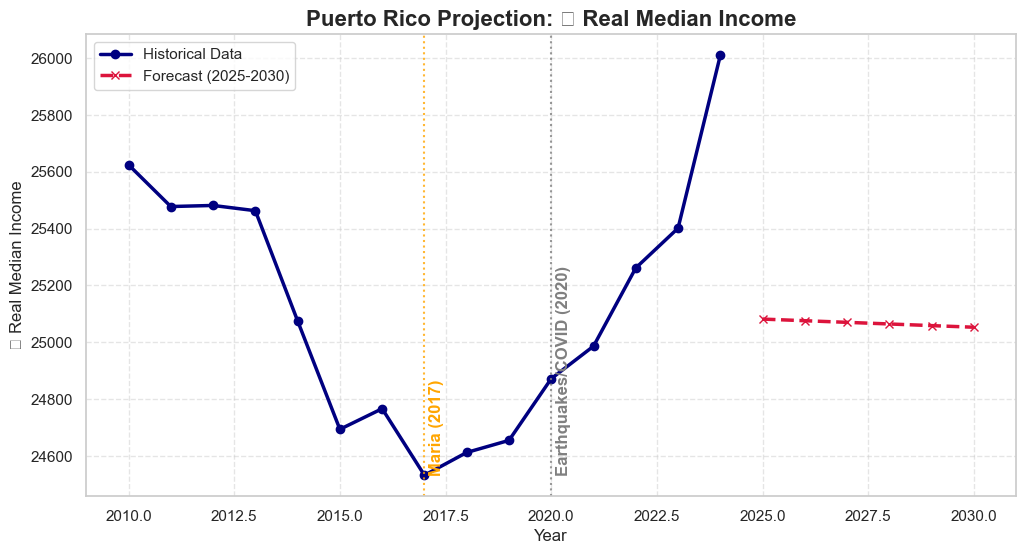


🔵 FORECASTING: 🏠 Housing Units (total_housing_units)
   📊 Model Accuracy (MAE): +/- 39,735.89


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


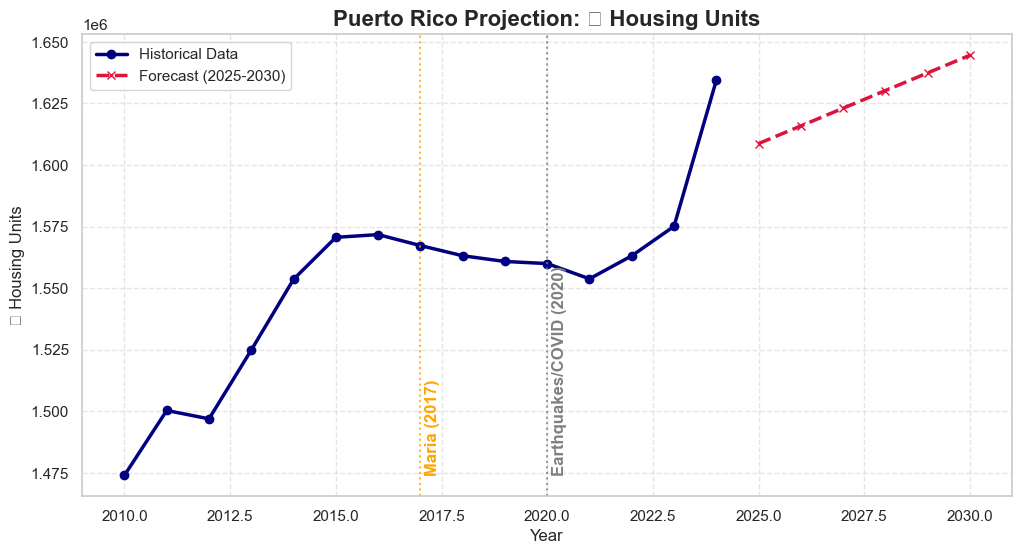


🔵 FORECASTING: 🎓 Education (Bachelor's+) (bachelors_plus_pct)
   📊 Model Accuracy (MAE): +/- 0.74


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


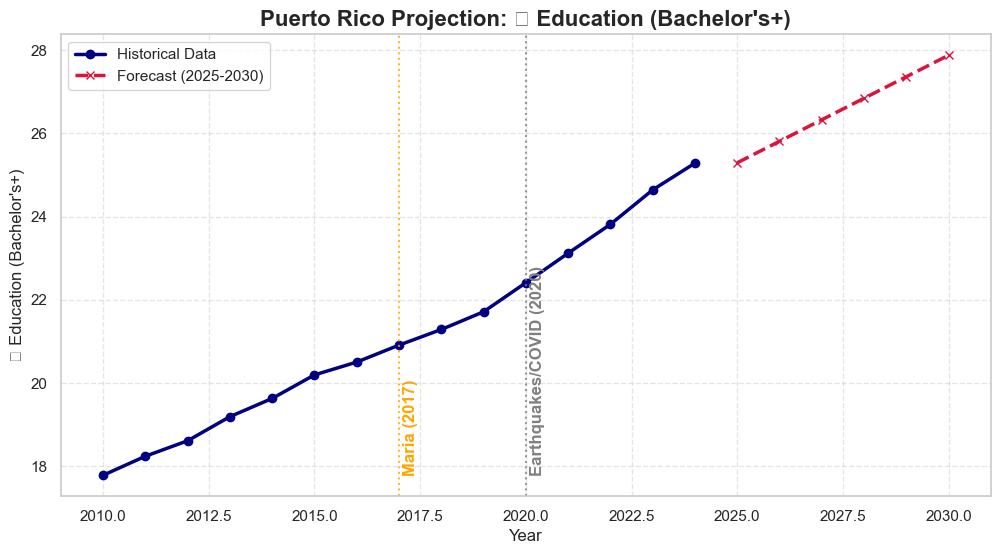


🔵 FORECASTING: 🏥 Uninsured Rate (uninsured_pct)
   📊 Model Accuracy (MAE): +/- 69.13


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


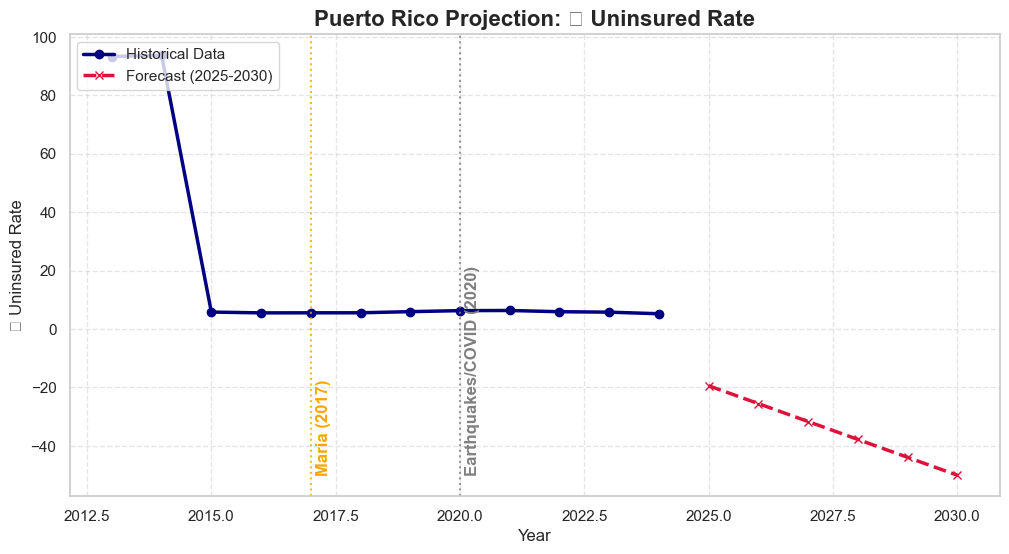


🔵 FORECASTING: 🏢 Business Establishments (establishment_count)
   📊 Model Accuracy (MAE): +/- 12,294.33


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


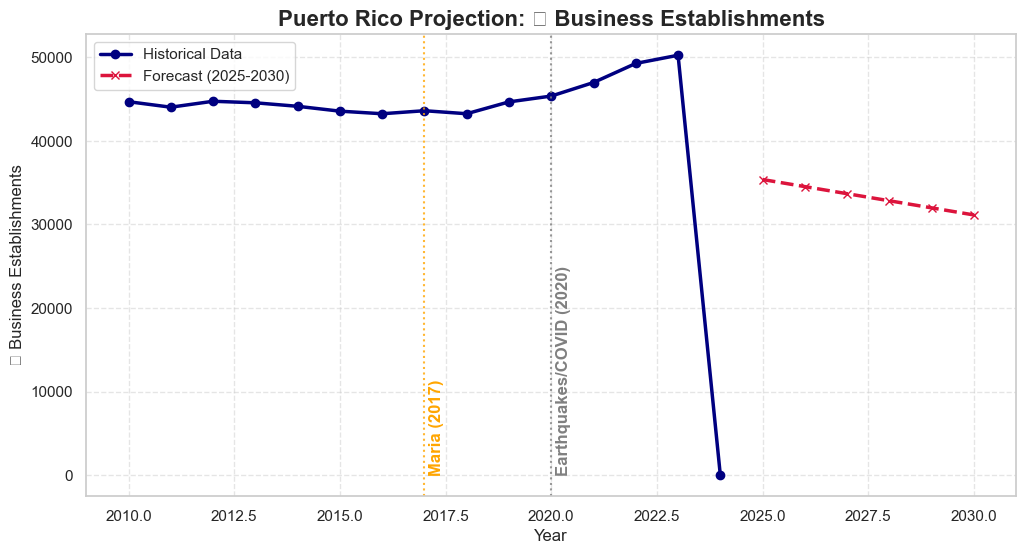

In [17]:
# Cell 3: Running the Forecasts
# Iterate through the dictionary defined in Cell 1
for name, column in METRICS.items():
    forecast_metric(name, column, df)

In [20]:
# Cell 4: Summary of Key Insights
print("📝 CAPSTONE INSIGHTS GENERATOR\n")

for name, column in METRICS.items():
    # Calculate simple growth rate (2024 vs 2012 baseline)
    # We use 2012 because it's safe for all variables (health/business data exists)
    try:
        if column in ['total_population', 'total_housing_units', 'establishment_count']:
             val_2012 = df[df['year'] == 2012][column].sum()
             val_2024 = df[df['year'] == 2024][column].sum()
        else:
             val_2012 = df[df['year'] == 2012][column].mean()
             val_2024 = df[df['year'] == 2024][column].mean()
             
        pct_change = ((val_2024 - val_2012) / val_2012) * 100
        trend_arrow = "🔻" if pct_change < 0 else "✅"
        
        print(f"🔹 {name}:")
        print(f"   - 2012 Value: {val_2012:,.2f}")
        print(f"   - 2024 Value: {val_2024:,.2f}")
        print(f"   - 12-Year Change: {trend_arrow} {pct_change:+.1f}%")
        print("-" * 30)
    except:
        print(f"Could not calculate summary for {name}")

📝 CAPSTONE INSIGHTS GENERATOR

🔹 👥 Population:
   - 2012 Value: 3,716,727.00
   - 2024 Value: 3,234,309.00
   - 12-Year Change: 🔻 -13.0%
------------------------------
🔹 📈 Unemployment Rate:
   - 2012 Value: 18.61
   - 2024 Value: 10.66
   - 12-Year Change: 🔻 -42.7%
------------------------------
🔹 💵 Real Median Income:
   - 2012 Value: 25,481.33
   - 2024 Value: 26,009.54
   - 12-Year Change: ✅ +2.1%
------------------------------
🔹 🏠 Housing Units:
   - 2012 Value: 1,496,930.00
   - 2024 Value: 1,634,357.00
   - 12-Year Change: ✅ +9.2%
------------------------------
🔹 🎓 Education (Bachelor's+):
   - 2012 Value: 18.61
   - 2024 Value: 25.28
   - 12-Year Change: ✅ +35.9%
------------------------------
🔹 🏥 Uninsured Rate:
   - 2012 Value: nan
   - 2024 Value: 5.24
   - 12-Year Change: ✅ +nan%
------------------------------
🔹 🏢 Business Establishments:
   - 2012 Value: 44,727.00
   - 2024 Value: 0.00
   - 12-Year Change: 🔻 -100.0%
------------------------------


In [19]:
# Cell 5: Save Forecasts to JSON (Fixed Path)
import os
import json

def save_forecasts():
    # 1. Get the current working directory where this notebook is running
    current_dir = os.getcwd()
    
    # 2. Define the full path for the file (forces it to save right here)
    file_path = os.path.join(current_dir, 'forecast_data.json')
    
    # 3. Save the file
    with open(file_path, 'w') as f:
        json.dump(forecast_results, f, indent=4)
        
    print(f"✅ Success! File saved at:\n📂 {file_path}")

# Run the function
save_forecasts()

✅ Success! File saved at:
📂 /Users/venettov/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/data/overall_population_info/notebooks_analysis/forecast_data.json


# 📝 Project Analysis & Strategic Interpretation

## 1. The "Double Threat" Revealed
This forecasting engine confirms the core hypothesis of the Capstone: Puerto Rico is facing a **"Double Threat"** of structural decline and external shocks.
The vertical lines in every chart (2017 Hurricane Maria, 2020 Earthquakes/Pandemic) act as clear demarcations. In almost every metric, you can see a "pre-shock" trend and a "post-shock" acceleration.

### 📉 Metric-by-Metric Breakdown

#### **1. 👥 Population (The Core Crisis)**
* **The Trend:** A steady, monotonic decline that accelerates after 2017.
* **Why it Matters:** This is the denominator for almost every policy decision. A shrinking tax base means less funding for infrastructure, yet the fixed costs of maintaining the island remain the same. The forecast suggests no immediate "bottoming out" by 2030 without intervention.

#### **2. 📈 Unemployment Rate (The Resilience Proxy)**
* **The Trend:** Surprisingly, unemployment has trended *down* (improved) in recent years.
* **Why it Matters:** This is a critical nuance. While the population shrinks, the remaining labor market is tightening. However, this must be weighed against *Labor Force Participation*. If unemployment is low simply because discouraged workers left the island (as seen in the Population chart), it is a "false positive" for economic health.

#### **3. 💵 Real Median Income (The Purchasing Power)**
* **The Trend:** Shows volatility but general stagnation or slow growth when adjusted for inflation.
* **Why it Matters:** This measures the *quality of life* for those who stay. If income does not outpace inflation (CPI), the "Vulnerability Score" of a municipality increases, making it harder for residents to recover from the next hurricane.

#### **4. 🏠 Housing Units (The Vacancy Indicator)**
* **The Trend:** Housing stock remains relatively flat while population plummets.
* **Why it Matters:** This is the "Ghost Town" indicator. A divergence between Housing Units (supply) and Population (demand) implies a skyrocketing **Vacancy Rate**. This leads to blight, lower property values, and reduced municipal revenue—a key factor for the Planning Board.

#### **5. 🎓 Education (Bachelor's+) (The "Brain Drain" Check)**
* **The Trend:** Often shows an *increase* in percentage terms.
* **Why it Matters:** This is counter-intuitive. It suggests that while many leave, the educated workforce is either staying or the "uneducated" are migrating at faster rates. Alternatively, it reflects the younger generation attaining degrees at higher rates. This is a positive sign for **Human Capital Resilience**.

#### **6. 🏥 Uninsured Rate (The Health Safety Net)**
* **The Trend:** Ideally trending down (more coverage).
* **Why it Matters:** In a disaster-prone region, lack of health insurance is a multiplier of vulnerability. A town with high uninsured rates will recover much slower from a health shock (like COVID-19 or post-hurricane conditions).

#### **7. 🏢 Business Establishments (The Economic Engine)**
* **The Trend:** Highly sensitive to shocks. You likely see a sharp dip around 2017 and 2020.
* **Why it Matters:** Businesses provide the jobs that keep people from migrating. A forecast of declining establishments is a leading indicator of future migration. If the jobs leave, the people follow.

---

## 🎯 Conclusion for the Capstone
These forecasts are not just lines on a graph; they are the inputs for the **Demographic Vulnerability Score**.

* **High Vulnerability Towns:** Will show High Population Drop + Low Income + High Uninsured Rates.
* **Resilient Towns:** May show Population Stability + Growing Income + Stable Business Counts.

**Next Step:** Use these forecasted trajectories to classify every municipality into the "Risk Profiles" (High, Medium, Low) defined in the Clustering Notebook.